In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
# library for treating nifti files
import nibabel as nib
import os
import modules as modules
from scipy.ndimage import shift
import pydicom

In [ ]:
'''Helper functions. Consider saving these in separate python file.'''
# Get coordinates of the FLUKA voxelcage
def get_voxelcage(dicom_path):
    script_type = "sort"
    Modality = modules.define_modality("impt")
    ct_list, slice_location_list, dose_list, struct_list, plan_list = modules.get_dicoms(dicom_path, script_type)
    slice_no = 1
    print(len(ct_list))
    cp = modules.get_dicom_ct_parameters(ct_list, slice_location_list, slice_no)
    pp = modules.get_dicom_rtplan_parameters(plan_list)[0]
    dicom_positions = {'x':[], 'y':[], 'z':[]}

    dicom_positions['x'].append((cp['patient_position'][0]-pp['isocenter_list'][0][0]-cp['pixel_size'][0]/2.0)/10)
    dicom_positions['z'].append((cp['patient_position'][2]-pp['isocenter_list'][0][2]-cp['slice_thickness']/2.0)/10)
    dicom_positions['y'].append((float(cp['patient_position'][1])-float(pp['isocenter_list'][0][1])-float(cp['pixel_size'][1])/2.0)/10)

    dicom_positions['x'].append(dicom_positions['x'][0]+(cp['columns']*cp['pixel_size'][0]/10.0))
    dicom_positions['y'].append(dicom_positions['y'][0]+(cp['rows']*cp['pixel_size'][1]/10.0))
    dicom_positions['z'].append(dicom_positions['z'][0]+(cp['number_of_slices']*cp['slice_thickness']/10))

    return dicom_positions

def convert_to_CT_coordinates(dicom_positions,dicom_path):
    CT_positions = {'x':[], 'y':[], 'z':[]}
    script_type = "sort"
    ct_list, slice_location_list, dose_list, struct_list, plan_list = modules.get_dicoms(dicom_path, script_type)
    slice_no = 1
    cp = modules.get_dicom_ct_parameters(ct_list, slice_location_list, slice_no)
    pp = modules.get_dicom_rtplan_parameters(plan_list)[0]

    CT_positions['x'].append(dicom_positions['x'][0]*10+cp['pixel_size'][0]/2.0 + pp['isocenter_list'][0][0])
    CT_positions['y'].append(dicom_positions['y'][0]*10+float(cp['pixel_size'][1])/2.0 + float(pp['isocenter_list'][0][1]))
    CT_positions['z'].append(dicom_positions['z'][0]*10+cp['slice_thickness']/2.0 + pp['isocenter_list'][0][2])

    return CT_positions,len(ct_list), cp['pixel_size'],cp['slice_thickness'],cp["columns"],cp["rows"],len(ct_list)

def save_as_nifti(hist,output_file,nifti_image):
    ref_img = nib.load(nifti_image)
    ref_affine = ref_img.affine
    # Setting pixelsize to 1 mm
    ref_affine[0][0] = -1 
    ref_affine[1][1] = -1
    ref_shape = ref_img.shape 

    your_volume = hist.astype(np.float32)
    new_img = nib.Nifti1Image(your_volume, ref_affine)

    # 4. Save to file
    nib.save(new_img,output_file)

def save_dose_as_nifti(volume, output_file, nifti_dose_ex):
    ref_img = nib.load(nifti_dose_ex)
    ref_affine = ref_img.affine
    img_to_save = nib.Nifti1Image(volume, ref_affine)
    nib.save(img_to_save,output_file)



In [69]:


overall_path = "/scratch/Anna/Proton_dose_reconstruction_vJune26/Data/HNC_data_dec25_field2/"
dicom_path = "/scratch/Anna/Proton_dose_reconstruction_vJune26/Anon_HNC_05_testlic_DICOMs"
# dose as nifti as image to copy
nifti_image = "/mnt/medisinskfysikk/Anna/Study2_DoseReconstruction/Results_4_dose_as_nifti.nii.gz"#"/scratch/Anna/Proton_dose_reconstruction_vJune26/Anon_HNC_05.nii.gz"

for folder in os.listdir(overall_path):
    folder_path = overall_path + folder + "/exiting/"

    coordinates_pg = []
    coordinates_fn = []

    for file in os.listdir(folder_path):
        data = np.load(folder_path + file)
        xsco = list(data["XSCO"])
        ysco = list(data["YSCO"])
        zsco = list(data["ZSCO"])
        id_list = list(data["id"])

        for i in range(len(id_list)):
            if id_list[i] == 8.0:
                coordinates_fn.append(np.array([xsco[i], ysco[i], zsco[i]]))
            if id_list[i] == 7.0:
                coordinates_pg.append(np.array([xsco[i], ysco[i], zsco[i]]))

    coordinates_pg = np.array(coordinates_pg)
    coordinates_fn = np.array(coordinates_fn)

    #dicom_positions = get_voxelcage(dicom_path)
    #print(dicom_positions)
    #CT_positions,_,pixel_size,_,shape_x,shape_y,shape_z = convert_to_CT_coordinates(dicom_positions,dicom_path)

    #shape_x_1mm = int(shape_x*pixel_size[0])
    #shape_y_1mm = int(shape_y*pixel_size[1])

    #print(shape_y_1mm)
    #print(shape_x_1mm)

    volume_shape = (537, 336, 109)#(shape_x_1mm, shape_y_1mm, shape_z)
    min_coords = [-25.339257, -6.309665, -17.921304]#[dicom_positions['x'][0],dicom_positions['y'][0], dicom_positions['z'][0]]
    max_coords = [28.360742, 27.290335, 14.778696]#[dicom_positions['x'][1],dicom_positions['y'][1], dicom_positions['z'][1]]

    #print("min_coords:", min_coords)
    #print("max_coords:", max_coords)

    edges = [
        np.linspace(min_coords[i], max_coords[i], volume_shape[i] + 1)
        for i in range(3)
    ]

    hist_pg, _ = np.histogramdd(coordinates_pg, bins=edges)
    hist_fn, _ = np.histogramdd(coordinates_fn, bins=edges)

    # Change based on Results folder
    output_folder = "/scratch/Anna/Proton_dose_reconstruction_vJune26/Exciting_patient_res1mm_dose_matched/HNC_dec25_field2/" + folder
    os.mkdir(output_folder)
    output_file_pg = output_folder + "/pg.nii.gz"
    output_file_fn = output_folder + "/fn.nii.gz"

    save_as_nifti(hist_pg, output_file_pg, nifti_image)
    save_as_nifti(hist_fn, output_file_fn, nifti_image)


In [65]:
nifti_image_fn = nib.load("/scratch/Anna/Proton_dose_reconstruction_vJune26/Exciting_patient_res1mm_dose_matched/Results_spot_5/fn.nii.gz").get_fdata()
nifti_image_pg = nib.load("/scratch/Anna/Proton_dose_reconstruction_vJune26/Exciting_patient_res1mm_dose_matched/Results_spot_5/fn.nii.gz").get_fdata()
dose_as_nifti = nib.load("/scratch/Anna/Proton_dose_reconstruction_vJune26/Dose/HNC_data_dec25_field1/Results_spot_5/dose.nii.gz").get_fdata()
'''binary_for_dose = nib.load("/scratch/Anna/Proton_dose_reconstruction_vJune26/HNC_mask_aligned.nii").get_fdata()

dose_image = pydicom.dcmread("/scratch/Anna/Proton_dose_reconstruction_vJune26/Data/HNC_data_dec25_field1/Results_spot_4/BNNLIS/FLUKA_DICOM/dose/FLK_Bio-dose1.1_Anon_HNC_05_testlic_AntObl_L_G80_u.dcm").pixel_array
dose_image = np.transpose(dose_image, (2,1,0))

#binary_for_dose_reshaped = np.transpose(binary_for_dose, (2,1,0))
dose_image_masked = dose_image * binary_for_dose#dose_as_nifti * binary_for_dose'''

print(nifti_image_fn.shape)
print(dose_as_nifti.shape)





(537, 336, 109)
(537, 336, 109)


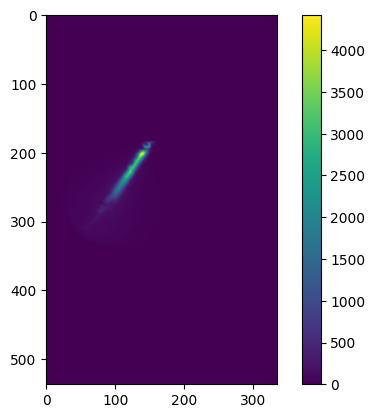

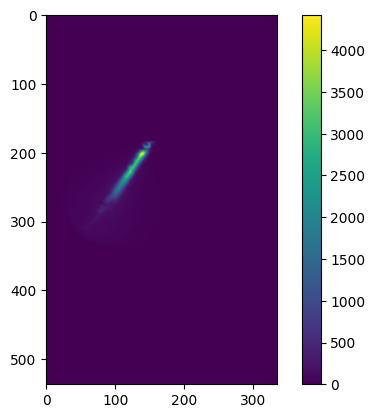

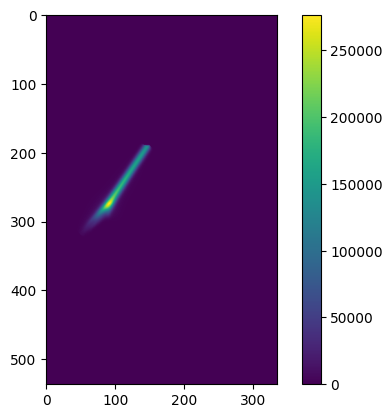

In [66]:

dose_image_masked = dose_as_nifti
image_2d_fn = np.zeros_like(nifti_image_fn[:,:,0])
image_2d_pg = np.zeros_like(nifti_image_pg[:,:,0])
image_2d_dose = np.zeros_like(dose_image_masked[:,:,0])

for i in range(nifti_image_fn.shape[2]):
    image_2d_fn += nifti_image_fn[:,:,i]

for i in range(nifti_image_pg.shape[2]):
    image_2d_pg += nifti_image_pg[:,:,i]

for j in range(dose_image_masked.shape[2]):
    image_2d_dose += dose_image_masked[:,:,j] 


plt.figure()
plt.imshow(image_2d_fn)
plt.colorbar()

plt.figure()
plt.imshow(image_2d_pg)
plt.colorbar()

plt.figure()
plt.imshow(image_2d_dose)
plt.colorbar()

In [12]:
dicom_positions = get_voxelcage(dicom_path)
CT_positions,_,pixel_size,_,shape_x,shape_y,shape_z = convert_to_CT_coordinates(dicom_positions,dicom_path)

volume_shape = (shape_x, shape_y, shape_z)
min_coords = [dicom_positions['x'][0],dicom_positions['y'][0], dicom_positions['z'][0]]
max_coords = [dicom_positions['x'][1],dicom_positions['y'][1], dicom_positions['z'][1]]

edges = [
    np.linspace(min_coords[i], max_coords[i], volume_shape[i] + 1)
    for i in range(3)
]

hist_pg, _ = np.histogramdd(coordinates_pg, bins=edges)
hist_fn, _ = np.histogramdd(coordinates_fn, bins=edges)

# Change based on Results folder
output_file_pg = "/scratch/Anna/Proton_dose_reconstruction_vJune26/Exciting_patient/pg.nii.gz"
output_file_fn = "/scratch/Anna/Proton_dose_reconstruction_vJune26/Exciting_patient/fn.nii.gz"

save_as_nifti(hist_pg, output_file_pg, nifti_image)
save_as_nifti(hist_fn, output_file_fn, nifti_image)



'''
shape_x_1mm = shape_x*pixel_size[0] # 310
shape_y_1mm = shape_y*pixel_size[1] # 310
volume_shape = (shape_x_1mm, shape_y_1mm, shape_z) '''

157


'\nshape_x_1mm = shape_x*pixel_size[0] # 310\nshape_y_1mm = shape_y*pixel_size[1] # 310\nvolume_shape = (shape_x_1mm, shape_y_1mm, shape_z) '

In [ ]:
import SimpleITK as sitk
    #dose_tp = pydicom.dcmread("/mnt/medisinskfysikk/Anna/Study2_DoseReconstruction/Treatment plans/HNC05_new_beam_data_1_1_3_grid/RP1.2.752.243.1.1.20251202122849065.1400.86371.dcm")
image = sitk.ReadImage("/mnt/medisinskfysikk/Anna/Study2_DoseReconstruction/Results_4_dose_as_nifti.nii.gz")
print("Origin:", image.GetOrigin())
print("Spacing: ", image.GetSpacing())

dose = pydicom.dcmread("/scratch/Anna/Proton_dose_reconstruction_vJune26/Data/HNC_data_dec25_field1/Results_spot_4/BNNLIS/FLUKA_DICOM/dose/FLK_Bio-dose1.1_Anon_HNC_05_testlic_AntObl_L_G80_u.dcm")

z_bins = dose.NumberOfFrames
dose_position = dose.ImagePositionPatient
print(dose_position)

'''
slice_thickness = dose.GridFrameOffsetVector[1] - dose.GridFrameOffsetVector[0] 
slice_location_list = []

for i in range(z_bins):
    slice_location_list.append(float(dose_position[2] + i*slice_thickness))

real_world_z_mm = slice_location_list[index[0]-1]
    # Use this to place the image plane
real_world_z_cm = real_world_z_mm / 10'''



Origin: (-267.4599914550781, -27.190000534057617, -243.5)
Spacing:  (1.0, 1.0, 3.0)
[-267.46, -27.19, -243.5]


'\nslice_thickness = dose.GridFrameOffsetVector[1] - dose.GridFrameOffsetVector[0] \nslice_location_list = []\n\nfor i in range(z_bins):\n    slice_location_list.append(float(dose_position[2] + i*slice_thickness))\n\nreal_world_z_mm = slice_location_list[index[0]-1]\n    # Use this to place the image plane\nreal_world_z_cm = real_world_z_mm / 10'

In [68]:
binary_for_dose = nib.load("/scratch/Anna/Proton_dose_reconstruction_vJune26/HNC_mask_aligned.nii").get_fdata()
dose_nifti_example = "/mnt/medisinskfysikk/Anna/Study2_DoseReconstruction/Results_4_dose_as_nifti.nii.gz"
output_path = "/scratch/Anna/Proton_dose_reconstruction_vJune26/Dose/HNC_data_dec25_field2/"

overall_path = "/scratch/Anna/Proton_dose_reconstruction_vJune26/Data/HNC_data_dec25_field2/"

for elem in os.listdir(overall_path):
    print(elem)
    dose_path_possibilities = overall_path + elem + "/BNNLIS/FLUKA_DICOM/dose"
    #print(os.listdir(dose_path_possibilities))
    for element in os.listdir(dose_path_possibilities):
        if "Bio-dose1.1" in element:
            dose_path = overall_path + elem + "/BNNLIS/FLUKA_DICOM/dose/" + element
            dose_image = pydicom.dcmread(dose_path).pixel_array
            dose_image = np.transpose(dose_image, (2,1,0))
            dose_image_masked = dose_image * binary_for_dose
            
            
            output_folder = output_path + elem
            os.mkdir(output_folder)
            output_file = output_folder + "/dose.nii.gz"
            save_dose_as_nifti(dose_image_masked,output_file,dose_nifti_example)





Results_spot_77
Results_spot_7
Results_spot_32
Results_spot_80
Results_spot_64
Results_spot_21
Results_spot_56
Results_spot_51
Results_spot_26
Results_spot_69
Results_spot_63
Results_spot_42
Results_spot_35
Results_spot_48
Results_spot_90
Results_spot_74
Results_spot_89
Results_spot_83
Results_spot_28
Results_spot_25
Results_spot_52
Results_spot_58
Results_spot_60
Results_spot_17
Results_spot_84
Results_spot_36
Results_spot_41
Results_spot_79
Results_spot_73
Results_spot_9
Results_spot_49
Results_spot_34
Results_spot_43
Results_spot_27
Results_spot_50
Results_spot_62
Results_spot_68
Results_spot_86
Results_spot_65
Results_spot_81
Results_spot_57
Results_spot_20
Results_spot_92
Results_spot_76
Results_spot_6
Results_spot_44
Results_spot_33
Results_spot_40
Results_spot_37
Results_spot_72
Results_spot_78
Results_spot_8
Results_spot_59
Results_spot_53
Results_spot_24
Results_spot_85
Results_spot_16
Results_spot_61
Results_spot_82
Results_spot_29
Results_spot_5
Results_spot_75
Results_spot_